<a href="https://colab.research.google.com/github/Baronlegend27/academic-research-to-financial-freedom/blob/main/papers/Heaton%2C%20J.B.%2C%20Polson%2C%20N.G.%2C%20%26%20Witte%2C%20J.H.%20(2015).%20Why%20Indexing%20Works/Why_indexing_works.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

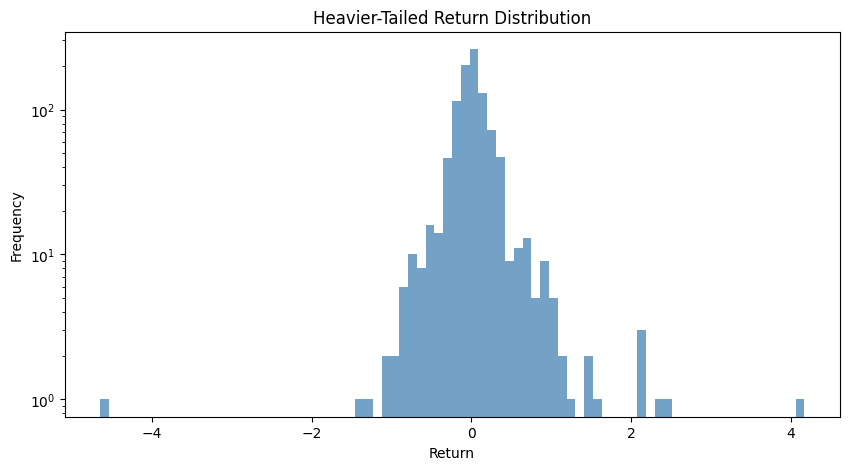

In [13]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

N = 1000
df = 2        # smaller = heavier tails
scale = 0.15
skew = 0.3

R = scale * np.random.standard_t(df, size=N)

# mild right skew
R = R + skew * np.maximum(R, 0)**2

plt.figure(figsize=(10,5))
plt.hist(R, bins=80, alpha=0.75, color='steelblue')
plt.yscale('log')
plt.title('Heavier-Tailed Return Distribution')
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.show()

This code simulates a realistic distribution of stock returns by generating values from a Student t distribution, which produces heavier tails than a normal distribution, and then slightly adjusting the positive values to create right skew. This is important because real financial returns tend to have more extreme outcomes and a few very large positive winners, so a fat tailed and slightly skewed distribution better reflects how markets actually behave.


Market Return: 3.05%

Portfolio         Avg    Std Dev      5th %     95th %   Beat Mkt
--------------------------------------------------------------
1%              2.94%     12.02%    -13.60%     23.30%      46.6%
5%              3.08%      5.33%     -5.27%     12.07%      49.7%
10%             3.00%      3.65%     -2.99%      9.10%      49.1%
25%             3.02%      2.12%     -0.49%      6.48%      49.4%
50%             3.07%      1.23%      1.06%      5.08%      50.6%


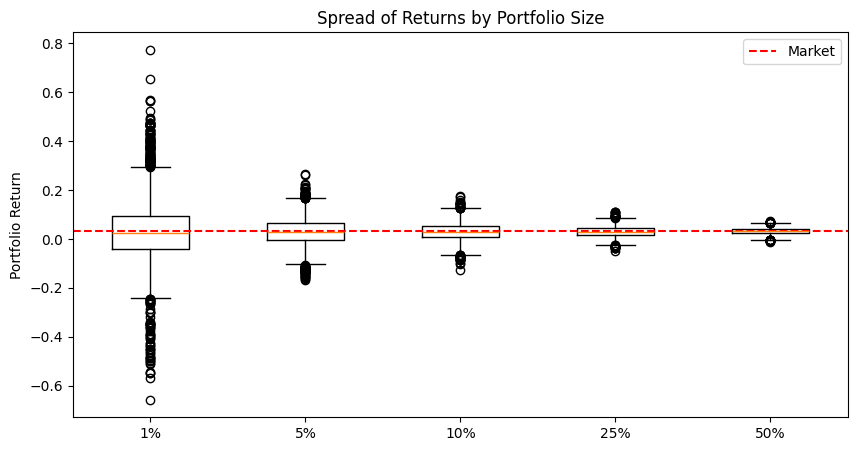

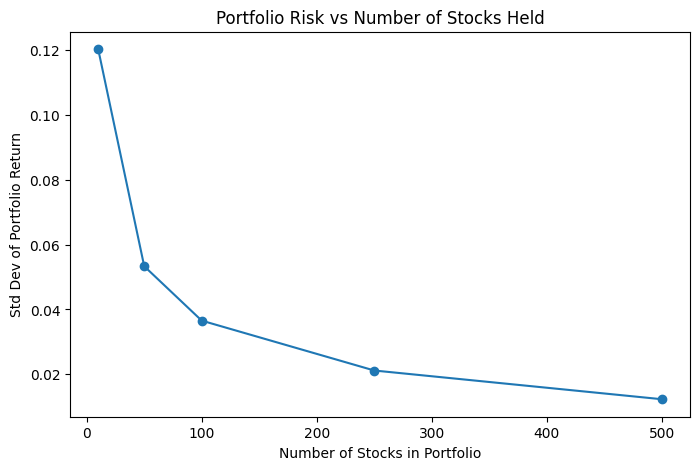

In [14]:
# --- PORTFOLIO SIZES ---
sizes = {
    "1%": int(0.01*N),
    "5%": int(0.05*N),
    "10%": int(0.10*N),
    "25%": int(0.25*N),
    "50%": int(0.50*N),
}

sims = 5000
results = {k: [] for k in sizes}

market_return = np.mean(R)

# --- SIMULATION ---
for _ in range(sims):
    for label, size in sizes.items():
        sample = np.random.choice(R, size=size, replace=False)
        results[label].append(np.mean(sample))

# --- SUMMARY NUMBERS ---
print(f"\nMarket Return: {market_return*100:.2f}%\n")

print(f"{'Portfolio':<12} {'Avg':>8} {'Std Dev':>10} {'5th %':>10} {'95th %':>10} {'Beat Mkt':>10}")
print("-"*62)

for label, vals in results.items():
    vals = np.array(vals)

    avg = np.mean(vals)
    std = np.std(vals)
    p5 = np.percentile(vals, 5)
    p95 = np.percentile(vals, 95)
    beat = np.mean(vals > market_return)

    print(f"{label:<12} {avg*100:>7.2f}% {std*100:>9.2f}% {p5*100:>9.2f}% {p95*100:>9.2f}% {beat*100:>9.1f}%")

# --- GRAPH 1: BOX PLOT (very intuitive spread comparison) ---
plt.figure(figsize=(10,5))
plt.boxplot(results.values(), tick_labels=results.keys())
plt.axhline(market_return, color='red', linestyle='--', label='Market')
plt.title("Spread of Returns by Portfolio Size")
plt.ylabel("Portfolio Return")
plt.legend()
plt.show()

# --- GRAPH 2: STANDARD DEVIATION VS PORTFOLIO SIZE ---
sizes_numeric = [sizes[k] for k in results.keys()]
stds = [np.std(results[k]) for k in results.keys()]

plt.figure(figsize=(8,5))
plt.plot(sizes_numeric, stds, marker='o')
plt.title("Portfolio Risk vs Number of Stocks Held")
plt.xlabel("Number of Stocks in Portfolio")
plt.ylabel("Std Dev of Portfolio Return")
plt.show()

This code simulates portfolio returns for different fractions of the market by repeatedly sampling random subsets of stocks from the generated returns. The results show that small portfolios have a wide range of possible returns, while larger portfolios stay close to the market average. The **box plot** visualizes this spread, showing that small portfolios can be very lucky or very unlucky, and the **risk vs. portfolio size graph** shows that volatility decreases as more stocks are included, highlighting the stabilizing effect of diversification.
